In [1]:
from datetime import datetime, time
from Database.TPData import TPData, TPDataDa
from OrderBook.OrderBook import OrderBookSnaps
from SynthSpread.spreadviewer_class import SpreadSingle
from Strategies.Sparse_momentum.ob_attributes import OB_attributes, TR_attributes
import pandas as pd
import numpy as np
from Utilities.excel_loaders import conn_out_xload
from Utilities.dfutils import dict_iloc
from Utilities.Storage import get_curr_storage_path
from Utilities.func_utils import load_arguments
import pickle
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import datetime as dt
import seaborn as sns

In [2]:
STORAGE_ = get_curr_storage_path()
l_path = '//192.168.10.91/data/Data/orderbooks/base/'

def load_ob(m, t, dt, p_d, bT, eT):
    ob_class = OrderBookSnaps(verbose=True)
    file_path = l_path + t.split('_')[0] + '/'
    file_name = m + '_' + t.split('_')[0] + '_' + p_d.strftime('%y%m%d') + '_' + dt.strftime('%y%m%d') + '.p'
    print('%s Loading OrderBook %d...' % (dt.strftime('%y-%m-%d'), 0))
    print(file_path + file_name)
    time_load = ob_class.import_data(file_path + file_name)
    print('OrderBook %d created in %d sec' % (0, time_load))
    # ob_class.LoB_truncate(thres_vol=1)
    return ob_class.LoB_select(bT, eT, freq=None)

def variables_from_instrument(instrument: str):
    result = {
        'mkt': None,
        'tenor': None,
        'tn': None
    }
    for x in ['de', 'fr', 'ttf']:
        if x in instrument:
            result['mkt'] = x
    result['tenor'] = instrument[-2]
    result['tn'] = int(instrument[-1])
    return result

In [3]:
dates_out = conn_out_xload()
allwd_broker_ids = [1441]

# ------------------ dataset prep ---------------------------------

# Load arguments
_INSTRUMENTS = ['dey1']
_START_DATE, _END_DATE = '2025-03-01', '2025-04-15'
ins_dicts = [variables_from_instrument(x) for x in _INSTRUMENTS]
n_s = 2
mkt_list = [ins_dict['mkt'] for ins_dict in ins_dicts]
tenor_list = [ins_dict['tenor'] for ins_dict in ins_dicts]
tn1_list = [ins_dict['tn'] for ins_dict in ins_dicts]
ts_lag = (lambda i: mkt_list[i] + tenor_list[i] + str(tn1_list[i]))(0)

tn2_list = []
prod = 'base'
venue_list = ['eex']
start_date = datetime.strptime(_START_DATE, '%Y-%m-%d').date()
end_date = datetime.strptime(_END_DATE, '%Y-%m-%d').date()

if not tn2_list:
    tn_list = [str(t1) for t1 in tn1_list]
else:
    tn_list = [str(t1) + '_' + str(t2) for (t1, t2) in zip(tn1_list, tn2_list)]

dates = pd.date_range(start_date, end_date, freq='B')

spread_class = SpreadSingle(mkt_list, tenor_list, tn1_list, tn2_list, venue_list)
product_date1 = spread_class.product_dates(dates, n_s, tn_bool=True)
product_date2 = spread_class.product_dates(dates, n_s, tn_bool=False)

start_time = time(9, 0, 0, 0)
end_time = time(17, 40, 0, 0)

gran = None

is_db = True
is_tr = True

if is_db:
    data_class = TPData() 
else:
    data_class = TPDataDa()



data_class.create_connection('OracleSQL')
inst_trades = data_class.get_trades_inst('de', venue_list, start_date, end_date, prod='base', spread_bool=False)
instrument_ts = inst_trades[inst_trades.eval('broker_id==1441')].index.drop_duplicates()


obAtt = OB_attributes(['b_price', 'a_price'])
df_orders = {}
df_trades = {}

for k, ds in enumerate(dates):
    if ds in dates_out:
        continue
    bT = datetime.combine(ds, start_time)
    eT = datetime.combine(ds, end_time)
    pd1_aux = [None if p is None else p[k] for p in product_date1]
    pd2_aux = [None if p is None else p[k] for p in product_date2]
    for (m, t, n, pd1, pd2) in zip(mkt_list, tenor_list, tn_list,
                                                pd1_aux, pd2_aux):
        i = m + t + str(n)
        # Order Book attributes
        ob_class = OrderBookSnaps(verbose=True)
        LoB, ts = load_ob(m, t, bT, pd1, bT, eT)
        ob_class.update_data(LoB, ts)
        orders = obAtt.prepare_ob_data(LoB, [0], aonn=True)
        # Trades
        data_class.create_connection('OracleSQL')
        trades = data_class.get_trades(m, t, venue_list, pd1, bT, eT,
                                            prod)
        trades = trades[trades['broker_id'].isin(allwd_broker_ids)]
        trades = trades.reset_index(names='datetime').drop_duplicates('datetime', keep='last').set_index('datetime')
        trades = data_class.clean_trades(trades, pd.DataFrame(orders), is_verbose=True)

        if i not in df_trades:
            df_trades[i] = trades
            df_orders[i] = pd.DataFrame(orders).set_index('timestamp')
        else:
            df_trades[i] = pd.concat([df_trades[i], trades])
            df_orders[i] = pd.concat([df_orders[i], pd.DataFrame(orders).set_index('timestamp')])

Connected to the database oracle
Disconnected from the database oracle
25-03-03 Loading OrderBook 0...
//192.168.10.91/data/Data/orderbooks/base/y/de_y_260101_250303.p
OrderBook 0 created in 18 sec
Connected to the database oracle
Disconnected from the database oracle
Deleting following trades 

Empty DataFrame
Columns: [price, volume, action, broker_id, own_trades]
Index: []


25-03-04 Loading OrderBook 0...
//192.168.10.91/data/Data/orderbooks/base/y/de_y_260101_250304.p
OrderBook 0 created in 22 sec
Connected to the database oracle
Disconnected from the database oracle
Deleting following trades 

Empty DataFrame
Columns: [price, volume, action, broker_id, own_trades]
Index: []


25-03-05 Loading OrderBook 0...
//192.168.10.91/data/Data/orderbooks/base/y/de_y_260101_250305.p
OrderBook 0 created in 28 sec
Connected to the database oracle
Disconnected from the database oracle
Deleting following trades 

Empty DataFrame
Columns: [price, volume, action, broker_id, own_trades]
Index: []



In [4]:
df_trades['dey1']

,price,volume,action,broker_id,own_trades
datetime,,,,,
2025-03-03 09:00:57.495030581,87.00,1,1,1441,False
2025-03-03 09:00:57.612058659,87.00,1,1,1441,False
2025-03-03 09:00:58.218863115,87.00,1,1,1441,False
2025-03-03 09:00:58.555367920,87.00,1,1,1441,False
2025-03-03 09:01:08.109247281,87.00,1,1,1441,False
...,...,...,...,...,...
2025-04-15 17:23:51.183619653,82.21,1,-1,1441,False
2025-04-15 17:24:15.253523696,82.30,1,-1,1441,False
2025-04-15 17:25:37.371471619,82.21,2,-1,1441,False


In [7]:
df = df_trades['dey1'][['price']].copy()
no_periods = 100
last_periods = no_periods

dist_list = []
index_list = []

for i in range(last_periods, len(df)-no_periods):
    last_prices = df.iloc[i-last_periods:i].dropna().copy()
    fut_prices = df.iloc[i+1:i+no_periods].dropna().copy()
    std = last_prices.diff().std().item() * np.sqrt(no_periods)
    act_price = df.iloc[i]
    fut_ret = fut_prices - act_price
    fut_ret_norm = fut_ret/std
    dist_list.append(fut_ret_norm['price'].to_list())
    index_list.append(i)



In [8]:
std

0.5440520001339149

<Axes: ylabel='Count'>

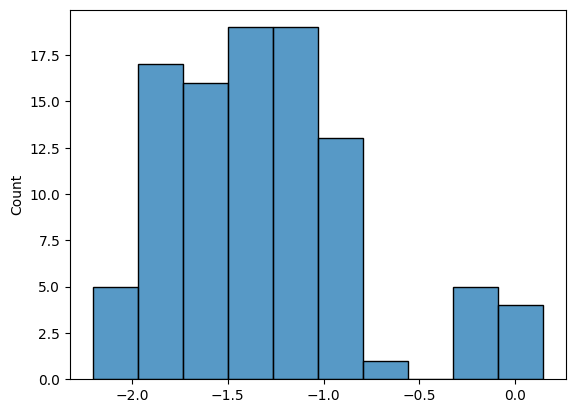

In [9]:
sns.histplot(dist_list[-1])


In [10]:
df_trades['dey1']['volume'].values

array([1, 1, 1, ..., 2, 1, 1], dtype=int64)

In [11]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from sklearn.linear_model import QuantileRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

# Data preparation
df = df_trades['dey1'][['price', 'volume']].reset_index(drop=True).copy()
date_index = df_trades['dey1'].index  # Datetime index
df['date'] = date_index  # Add date_index as a column for grouping

# Step 1: Compute Distributions and Predictors
no_periods = 100
last_periods = no_periods

dist_list = []
index_list = []
std_list = []  # Store std for each time point to reconstruct prices
current_prices = []  # Store current price for reconstruction

for i in range(last_periods, len(df) - no_periods):
    last_prices = df.iloc[i - last_periods:i]['price'].copy()
    fut_prices = df.iloc[i + 1:i + no_periods]['price'].copy()
    std = last_prices.diff().std() * np.sqrt(no_periods)
    if std == 0 or np.isnan(std):
        std = 1e-6  # Avoid division by zero
    act_price = df.iloc[i]['price']
    fut_ret = fut_prices - act_price
    fut_ret_norm = fut_ret / std
    dist_list.append(fut_ret_norm.to_list())
    index_list.append(i)
    std_list.append(std)
    current_prices.append(act_price)

# Convert to numpy arrays
dist_array = np.array(dist_list)
std_list = np.array(std_list)
current_prices = np.array(current_prices)

# Step 2: Compute Quantiles from Distributions
n_quantiles = 5
quantiles = np.array([0.05, 0.25, 0.5, 0.75, 0.95])
Y = np.zeros((len(dist_list), n_quantiles))

for i in range(len(dist_list)):
    distribution = dist_array[i]
    Y[i, :] = np.quantile(distribution, quantiles)

# Step 3: Construct Predictor Matrix X
volatility = np.array([df.iloc[max(0, idx - last_periods):idx]['price'].diff().std() for idx in index_list])
momentum = np.array([df.iloc[idx]['price'] - df.iloc[max(0, idx - 500)]['price'] if idx > 500 else 0 for idx in index_list])
volume = np.array([df.iloc[idx]['volume'] for idx in index_list])

# Compute 100-period moving average
ma_period = 100
moving_average = np.array([
    df.iloc[max(0, idx - ma_period + 1):idx + 1]['price'].mean() if idx >= ma_period - 1 else np.nan 
    for idx in index_list
])

# Compute distance from current price to moving average, normalized by volatility
# Use the same volatility computed earlier; handle cases where volatility is 0 or NaN
current_prices = np.array([df.iloc[idx]['price'] for idx in index_list])
distance_to_ma = current_prices - moving_average
distance_to_ma_normalized = np.zeros_like(distance_to_ma)
for i, (dist, vol) in enumerate(zip(distance_to_ma, volatility)):
    if vol == 0 or np.isnan(vol) or np.isnan(dist):
        distance_to_ma_normalized[i] = 0  # Default to 0 if volatility is 0 or data is missing
    else:
        distance_to_ma_normalized[i] = dist / vol

# Handle NaN values in moving average (for early indices where we don't have enough data)
moving_average = np.nan_to_num(moving_average, nan=0.0)

# Construct the predictor matrix X
X = np.column_stack(( momentum, volatility, volume, moving_average, distance_to_ma_normalized))
valid_idx = ~np.any(np.isnan(X), axis=1)
X = X[valid_idx, :]
Y = Y[valid_idx, :]
index_list = np.array(index_list)[valid_idx]
std_list = std_list[valid_idx]
current_prices = current_prices[valid_idx]

# Step 4: Map Indices to Dates
index_to_date = df['date'].iloc[index_list].reset_index(drop=True)

# Step 5: Group Data by Day
data_by_day = pd.DataFrame({
    'date': index_to_date,
    'X': list(X),
    'Y': list(Y),
    'index': index_list,
    'std': std_list,
    'current_price': current_prices
})
data_by_day['date'] = pd.to_datetime(data_by_day['date'])
data_by_day['day'] = data_by_day['date'].dt.date
daily_groups = data_by_day.groupby('day')

# Step 6: Rolling Regression for Last 7 Days
last_n_days = 7  # Forecast for the last 7 days
window_days = 7  # Train on the previous 7 days

# Get all unique days in the data
all_days = sorted(daily_groups.groups.keys())
forecast_days = all_days[-last_n_days:]  # Last 7 days

# Store forecasts and actuals for metrics
forecasted_expected_prices = []
actual_prices = []
forecasted_quantiles = []  # Store (5th, 95th) quantiles for coverage
forecasted_directions = []
actual_directions = []

In [12]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import wasserstein_distance
from scipy.special import rel_entr
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb

# Data preparation
df = df_trades['dey1'][['price', 'volume']].reset_index(drop=True).copy()
date_index = df_trades['dey1'].index  # Datetime index
df['date'] = date_index  # Add date_index as a column for grouping

# Step 1: Compute Distributions and Predictors
no_periods = 100
last_periods = no_periods

dist_list = []
index_list = []
std_list = []
current_prices = []

for i in range(last_periods, len(df) - no_periods):
    last_prices = df.iloc[i - last_periods:i]['price'].copy()
    fut_prices = df.iloc[i + 1:i + no_periods]['price'].copy()
    std = last_prices.diff().std() * np.sqrt(no_periods)
    if std == 0 or np.isnan(std):
        std = 1e-6
    act_price = df.iloc[i]['price']
    fut_ret = fut_prices - act_price
    fut_ret_norm = fut_ret / std
    dist_list.append(fut_ret_norm.to_list())
    index_list.append(i)
    std_list.append(std)
    current_prices.append(act_price)

dist_array = np.array(dist_list)
std_list = np.array(std_list)
current_prices = np.array(current_prices)

# Step 2: Bin the Distributions into Histograms
n_bins = 20  # Number of bins for the histogram
bin_edges = np.linspace(np.min(dist_array), np.max(dist_array), n_bins + 1)  # Common bin edges for all distributions
Y_dist = np.zeros((len(dist_list), n_bins))  # Shape: (n_samples, n_bins)

for i in range(len(dist_list)):
    distribution = dist_array[i]
    hist, _ = np.histogram(distribution, bins=bin_edges, density=True)
    Y_dist[i, :] = hist / np.sum(hist)  # Normalize to get probabilities (PDF)

# Step 3: Construct Predictor Matrix X
volatility = np.array([df.iloc[max(0, idx - last_periods):idx]['price'].diff().std() for idx in index_list])

momentum_lookback = 50
momentum = np.array([
    df.iloc[idx]['price'] - df.iloc[max(0, idx - momentum_lookback)]['price'] if idx > momentum_lookback else 0 
    for idx in index_list
])

volume = np.array([df.iloc[idx]['volume'] for idx in index_list])

ma_period = 100
moving_average = np.array([
    df.iloc[max(0, idx - ma_period + 1):idx + 1]['price'].mean() if idx >= ma_period - 1 else np.nan 
    for idx in index_list
])

current_prices_array = np.array([df.iloc[idx]['price'] for idx in index_list])
distance_to_ma = current_prices_array - moving_average
distance_to_ma_normalized = np.zeros_like(distance_to_ma)
for i, (dist, vol) in enumerate(zip(distance_to_ma, volatility)):
    if vol == 0 or np.isnan(vol) or np.isnan(dist):
        distance_to_ma_normalized[i] = 0
    else:
        distance_to_ma_normalized[i] = dist / vol

moving_average = np.nan_to_num(moving_average, nan=0.0)

X = np.column_stack((momentum, volatility, volume, moving_average, distance_to_ma_normalized))
valid_idx = ~np.any(np.isnan(X), axis=1)
X = X[valid_idx, :]
Y_dist = Y_dist[valid_idx, :]
index_list = np.array(index_list)[valid_idx]
std_list = std_list[valid_idx]
current_prices = current_prices[valid_idx]
dist_array = dist_array[valid_idx]

# Step 4: Map Indices to Dates
index_to_date = df['date'].iloc[index_list].reset_index(drop=True)

# Step 5: Group Data by Day
data_by_day = pd.DataFrame({
    'date': index_to_date,
    'X': list(X),
    'Y_dist': list(Y_dist),  # Store the binned distribution (histogram probabilities)
    'index': index_list,
    'std': std_list,
    'current_price': current_prices
})
data_by_day['date'] = pd.to_datetime(data_by_day['date'])
data_by_day['day'] = data_by_day['date'].dt.date
daily_groups = data_by_day.groupby('day')

# Step 6: Rolling Regression for Last 7 Days
last_n_days = 7
window_days = 7
all_days = sorted(daily_groups.groups.keys())
forecast_days = all_days[-last_n_days:]

# Functions for distribution prediction and evaluation
def predict_distribution(X, models):
    predictions = np.zeros((X.shape[0], len(models)))
    for i, model in enumerate(models):
        predictions[:, i] = model.predict(X)
    # Ensure predictions are non-negative and sum to 1 (like a PDF)
    predictions = np.maximum(predictions, 1e-10)
    predictions = predictions / np.sum(predictions, axis=1, keepdims=True)
    return predictions

def interpolate_distribution_from_histogram(bin_probs, bin_edges):
    # Convert bin probabilities (PDF) to CDF
    pdf = bin_probs
    x = (bin_edges[:-1] + bin_edges[1:]) / 2  # Midpoints of bins
    dx = bin_edges[1] - bin_edges[0]
    cdf_vals = np.cumsum(pdf) * dx
    cdf_vals = np.clip(cdf_vals, 0, 1)  # Ensure CDF is between 0 and 1
    # Interpolate CDF
    cdf = interp1d(x, cdf_vals, kind='linear', fill_value=(0, 1), bounds_error=False)
    x_new = np.linspace(x[0], x[-1], 100)
    cdf_vals_new = cdf(x_new)
    pdf_new = np.gradient(cdf_vals_new, x_new)
    pdf_new = np.maximum(pdf_new, 1e-10)
    area = np.sum(pdf_new) * (x_new[1] - x_new[0])
    pdf_new = pdf_new / area
    return x_new, pdf_new, cdf

def compute_expected_value(x, pdf):
    return np.sum(x * pdf) * (x[1] - x[0])

# Lists to store distribution comparison metrics
ks_distances = []
wasserstein_distances = []
kl_divergences = []

# Rolling regression
for forecast_day in forecast_days:
    day_idx = all_days.index(forecast_day)
    if day_idx < window_days:
        print(f"Skipping {forecast_day}: Not enough previous days for training.")
        continue
    
    train_days = all_days[day_idx - window_days:day_idx]
    test_day_data = daily_groups.get_group(forecast_day)
    
    # Collect training data
    X_train = []
    Y_train_dist = []
    for train_day in train_days:
        day_data = daily_groups.get_group(train_day)
        X_train.extend(day_data['X'].values)
        Y_train_dist.extend(day_data['Y_dist'].values)
    
    X_train = np.array(X_train)
    Y_train_dist = np.array(Y_train_dist)  # Shape: (n_samples, n_bins)
    
    if len(X_train) == 0 or len(Y_train_dist) == 0:
        print(f"Skipping {forecast_day}: No training data available.")
        continue
    
    # Standardize predictors
    X_train_raw = X_train.copy()
    scaler = StandardScaler()
    variances = np.var(X_train_raw, axis=0)
    if np.any(variances == 0):
        print("Warning: Zero variance in predictors:", variances)
        for j in range(X_train_raw.shape[1]):
            if variances[j] == 0:
                X_train_raw[:, j] += np.random.normal(0, 1e-6, X_train_raw.shape[0])
    
    X_train = scaler.fit_transform(X_train_raw)
    
    # Diagnostics
    print(f"\nTraining for forecast day: {forecast_day}")
    print("Shape of X_train:", X_train.shape)
    print("Shape of Y_train_dist:", Y_train_dist.shape)
    print("Variance of X_train (before standardization):", np.var(X_train_raw, axis=0))
    print("Variance of X_train (after standardization):", np.var(X_train, axis=0))
    print("Proportion of zeros in X_train (before standardization):")
    for j in range(X_train_raw.shape[1]):
        print(f"Predictor {j}: {np.mean(X_train_raw[:, j] == 0):.4f}")
    X_train_df = pd.DataFrame(X_train, columns=['momentum', 'volatility', 'volume', 'moving_average', 'distance_to_ma_normalized'])
    print("Correlation matrix of X_train:")
    print(X_train_df.corr())
    
    # Train a LightGBM model for each bin
    lgb_models = []
    for i in range(n_bins):
        params = {
            'objective': 'regression',  # Use standard regression to predict bin probabilities
            'n_estimators': 100,
            'random_state': 42
        }
        lgb_model = lgb.LGBMRegressor(**params)
        Y_train = Y_train_dist[:, i]  # Shape: (n_samples,)
        print(f"Shape of Y_train for bin {i}: {Y_train.shape}")
        lgb_model.fit(X_train, Y_train)
        lgb_models.append(lgb_model)
    
    # Print feature importances
    for i, lgb_model in enumerate(lgb_models):
        print(f"Feature importances for bin {i}:")
        importances = pd.Series(lgb_model.feature_importances_, index=['momentum', 'volatility', 'volume', 'moving_average', 'distance_to_ma_normalized'])
        print(importances)
        print()
    
    # Forecast for each data point in the test day
    X_test = np.array(list(test_day_data['X'].values))
    X_test = scaler.transform(X_test)
    current_prices_test = test_day_data['current_price'].values
    std_test = test_day_data['std'].values
    indices_test = test_day_data['index'].values
    
    for i in range(len(X_test)):
        # Predict the distribution (histogram probabilities)
        dist_preds = predict_distribution(X_test[i:i+1, :], lgb_models)  # Shape: (1, n_bins)
        dist_preds = dist_preds[0]  # Shape: (n_bins,)
        
        # Reconstruct the distribution from the predicted histogram
        x_forecast, pdf_forecast, cdf_forecast = interpolate_distribution_from_histogram(dist_preds, bin_edges)
        expected_norm_return = compute_expected_value(x_forecast, pdf_forecast)
        
        current_price = current_prices_test[i]
        std = std_test[i]
        expected_price = current_price + (expected_norm_return * std)
        
        idx = indices_test[i]
        if idx + no_periods < len(df):
            actual_norm_returns = dist_array[i]  # Already computed during data prep
            hist_actual, _ = np.histogram(actual_norm_returns, bins=bin_edges, density=True)
            hist_actual = hist_actual / np.sum(hist_actual)  # Normalize to probabilities
            x_actual, pdf_actual, cdf_actual = interpolate_distribution_from_histogram(hist_actual, bin_edges)
        else:
            actual_norm_returns = np.array([])
            x_actual, pdf_actual, cdf_actual = None, None, None
        
        if actual_norm_returns.size > 0:
            common_x = np.linspace(min(x_forecast.min(), x_actual.min()), 
                                 max(x_forecast.max(), x_actual.max()), 100)
            cdf_forecast_vals = cdf_forecast(common_x)
            cdf_actual_vals = cdf_actual(common_x)
            
            ks_stat = np.max(np.abs(cdf_forecast_vals - cdf_actual_vals))
            ks_distances.append(ks_stat)
            
            wass_dist = wasserstein_distance(x_forecast, x_actual, pdf_forecast, pdf_actual)
            wasserstein_distances.append(wass_dist)
            
            pdf_forecast_interp = np.gradient(cdf_forecast_vals, common_x)
            pdf_forecast_interp = np.maximum(pdf_forecast_interp, 1e-10)
            pdf_forecast_interp /= (np.sum(pdf_forecast_interp) * (common_x[1] - common_x[0]))
            pdf_actual_interp = np.gradient(cdf_actual_vals, common_x)
            pdf_actual_interp = np.maximum(pdf_actual_interp, 1e-10)
            pdf_actual_interp /= (np.sum(pdf_actual_interp) * (common_x[1] - common_x[0]))
            
            kl_div = np.sum(rel_entr(pdf_actual_interp, pdf_forecast_interp)) * (common_x[1] - common_x[0])
            kl_divergences.append(kl_div)
            
            print(f"Forecast at time {idx} (Date: {test_day_data['date'].iloc[i]}):")
            print(f"Current Price: {current_price:.2f}")
            print(f"Expected Normalized Return: {expected_norm_return:.4f}")
            print(f"Expected Price (for reference): {expected_price:.2f}")
            print(f"Forecasted PDF (first 5 points): {pdf_forecast[:5]}")
            print(f"Actual PDF (first 5 points): {pdf_actual[:5]}")
            print(f"KS Distance: {ks_stat:.4f}")
            print(f"Wasserstein Distance: {wass_dist:.4f}")
            print(f"KL Divergence (actual || forecast): {kl_div:.4f}")
            print()
        else:
            print(f"Forecast at time {idx} (Date: {test_day_data['date'].iloc[i]}):")
            print(f"Current Price: {current_price:.2f}")
            print(f"Expected Normalized Return: {expected_norm_return:.4f}")
            print(f"Expected Price (for reference): {expected_price:.2f}")
            print(f"Forecasted PDF (first 5 points): {pdf_forecast[:5]}")
            print(f"Actual distribution not available (insufficient future data).")
            print()

# Compute and print average distribution comparison metrics
if len(ks_distances) > 0:
    print(f"Average KS Distance: {np.mean(ks_distances):.4f}")
    print(f"Average Wasserstein Distance: {np.mean(wasserstein_distances):.4f}")
    print(f"Average KL Divergence (actual || forecast): {np.mean(kl_divergences):.4f}")
else:
    print("No distribution comparisons available.")

ModuleNotFoundError: No module named 'lightgbm'

<Axes: ylabel='Count'>

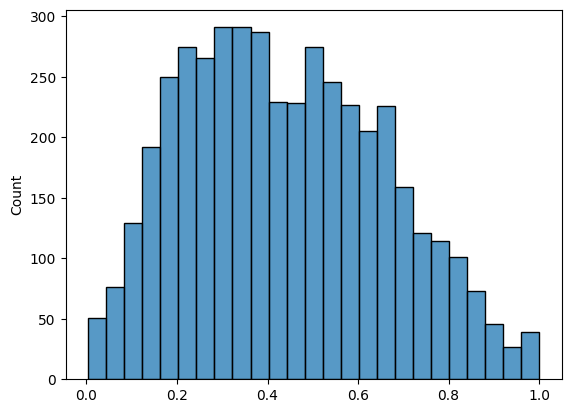

In [ ]:
sns.histplot(ks_distances)

<Axes: ylabel='Count'>

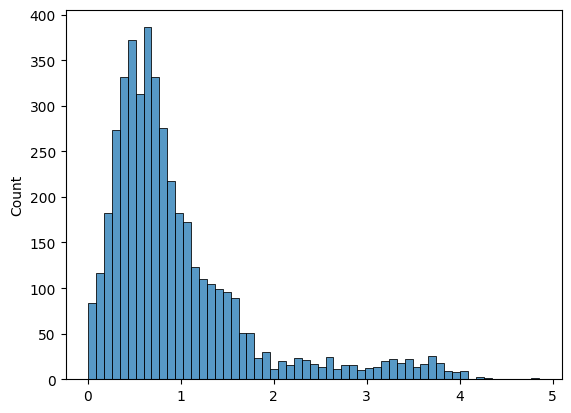

In [ ]:
sns.histplot(wasserstein_distances)

<Axes: ylabel='Count'>

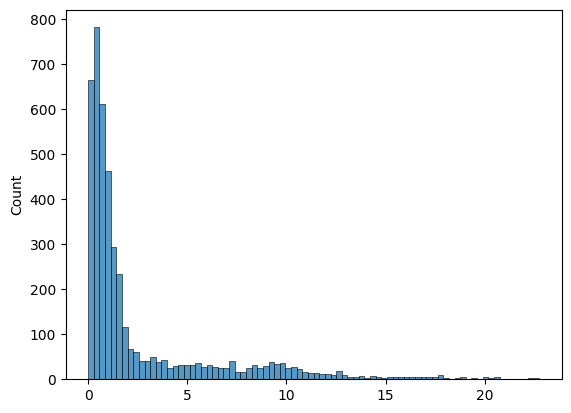

In [ ]:
sns.histplot(kl_divergences)

<Axes: xlabel='date'>

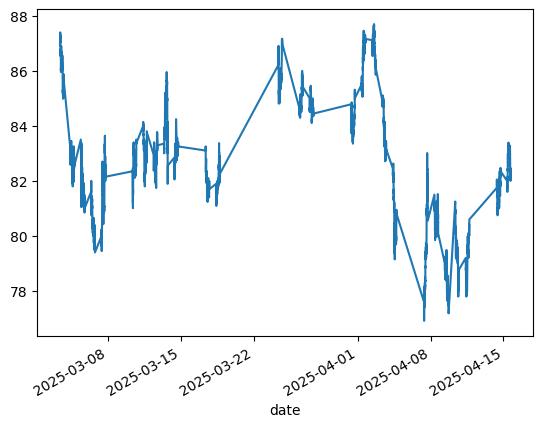

In [ ]:
df.set_index('date')['price'].plot()

GPU is available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Training for forecast day: 2025-04-07
Shape of X_train: (3962, 5)
Shape of Y_train_images: (3962, 128, 128, 1)
Epoch 1/50
62/62 [==============================] - 9s 79ms/step - loss: 0.0992
Epoch 2/50
62/62 [==============================] - 4s 60ms/step - loss: 0.0279
Epoch 3/50
62/62 [==============================] - 4s 60ms/step - loss: 0.0261
Epoch 4/50
62/62 [==============================] - 4s 60ms/step - loss: 0.0258
Epoch 5/50
62/62 [==============================] - 4s 60ms/step - loss: 0.0253
Epoch 6/50
62/62 [==============================] - 4s 60ms/step - loss: 0.0249
Epoch 7/50
62/62 [==============================] - 4s 60ms/step - loss: 0.0244
Epoch 8/50
62/62 [==============================] - 4s 60ms/step - loss: 0.0237
Epoch 9/50
62/62 [==============================] - 4s 60ms/step - loss: 0.0232
Epoch 10/50
62/62 [==============================] - 4s 60ms/step - loss: 0.0227
Ep

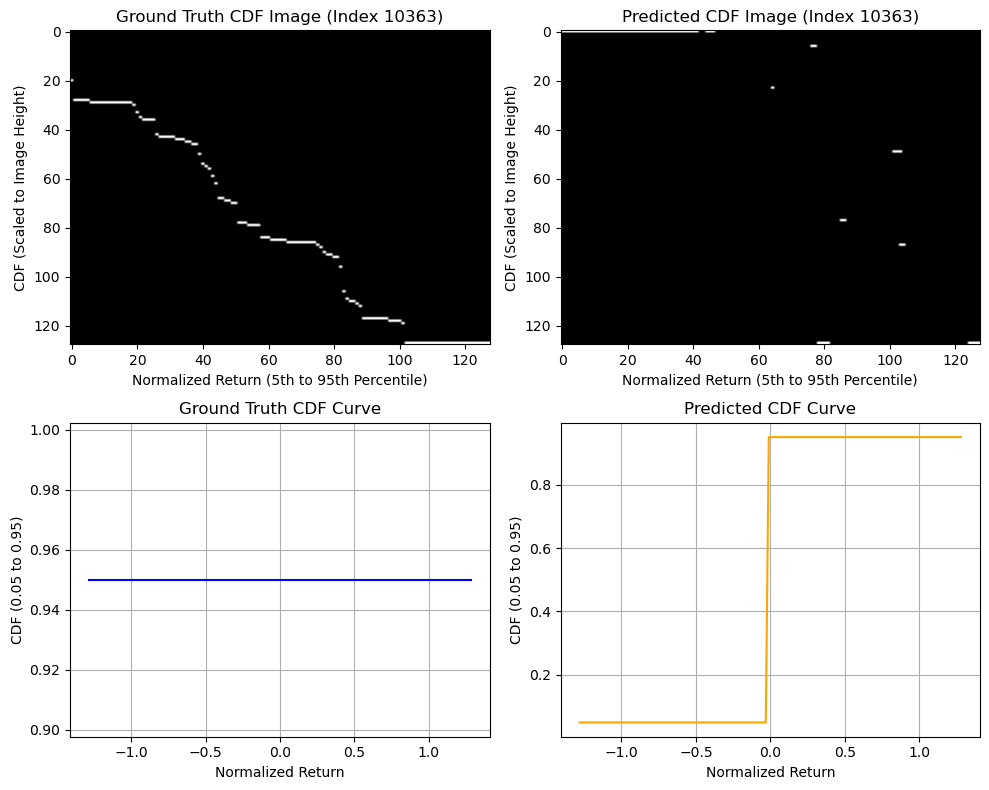

Forecast at time 10363 (Date: 2025-04-07 09:00:25.612974315):
Current Price: 77.60
Expected Normalized Return: -0.0202
Expected Price (for reference): 77.59
Forecasted CDF Values (first 5 points): [0.05 0.05 0.05 0.05 0.05]
Actual CDF Values (first 5 points): [0. 0. 0. 0. 0.]
KS Distance: 0.7320
Wasserstein Distance: 0.3519
KL Divergence (actual || forecast): 19.9848

Forecast at time 10364 (Date: 2025-04-07 09:01:01.968113300):
Current Price: 77.50
Expected Normalized Return: 0.1008
Expected Price (for reference): 77.83
Forecasted CDF Values (first 5 points): [0.05 0.05 0.05 0.05 0.05]
Actual CDF Values (first 5 points): [0. 0. 0. 0. 0.]
KS Distance: 0.6195
Wasserstein Distance: 0.2667
KL Divergence (actual || forecast): 21.0492

Forecast at time 10365 (Date: 2025-04-07 09:02:55.738088909):
Current Price: 77.50
Expected Normalized Return: 0.1008
Expected Price (for reference): 77.83
Forecasted CDF Values (first 5 points): [0.05 0.05 0.05 0.05 0.05]
Actual CDF Values (first 5 points): 

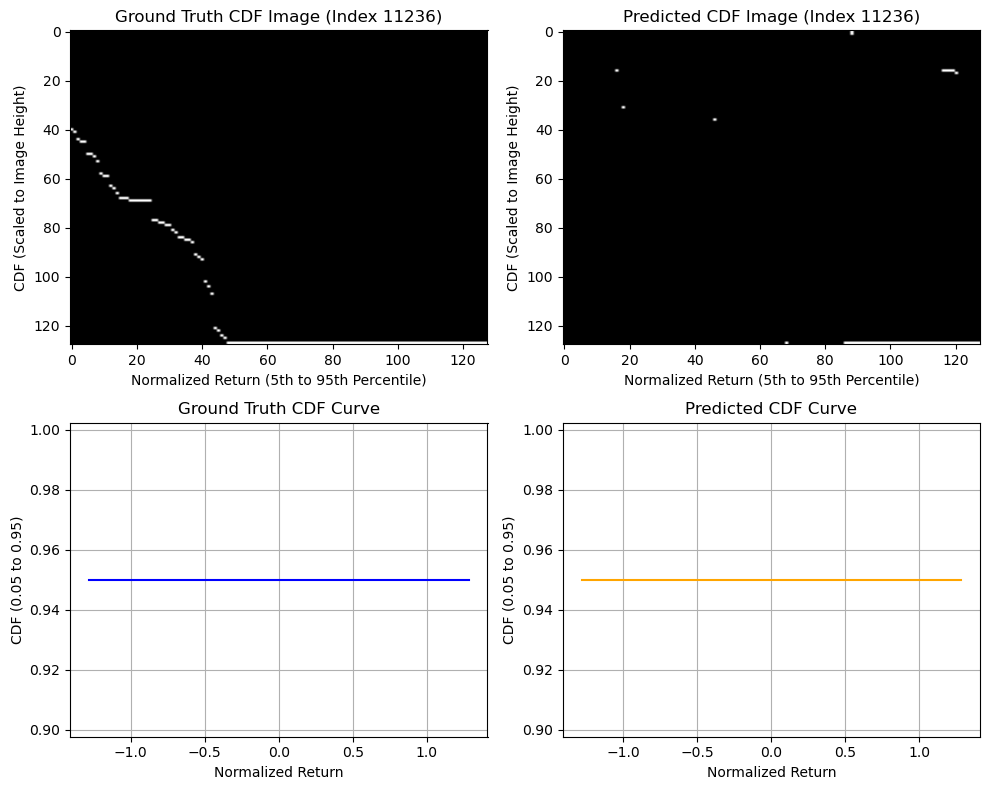

Forecast at time 11236 (Date: 2025-04-08 09:00:19.079573711):
Current Price: 81.50
Expected Normalized Return: -0.0000
Expected Price (for reference): 81.50
Forecasted CDF Values (first 5 points): [0.95 0.95 0.95 0.95 0.95]
Actual CDF Values (first 5 points): [0. 0. 0. 0. 0.]
KS Distance: 0.9500
Wasserstein Distance: 0.4635
KL Divergence (actual || forecast): 1.2764

Forecast at time 11237 (Date: 2025-04-08 09:00:19.592079023):
Current Price: 81.50
Expected Normalized Return: -0.0000
Expected Price (for reference): 81.50
Forecasted CDF Values (first 5 points): [0.95 0.95 0.95 0.95 0.95]
Actual CDF Values (first 5 points): [0. 0. 0. 0. 0.]
KS Distance: 0.9500
Wasserstein Distance: 0.4636
KL Divergence (actual || forecast): 1.2699

Forecast at time 11238 (Date: 2025-04-08 09:02:24.835619047):
Current Price: 81.25
Expected Normalized Return: -0.4640
Expected Price (for reference): 80.68
Forecasted CDF Values (first 5 points): [0.05 0.05 0.05 0.05 0.05]
Actual CDF Values (first 5 points): 

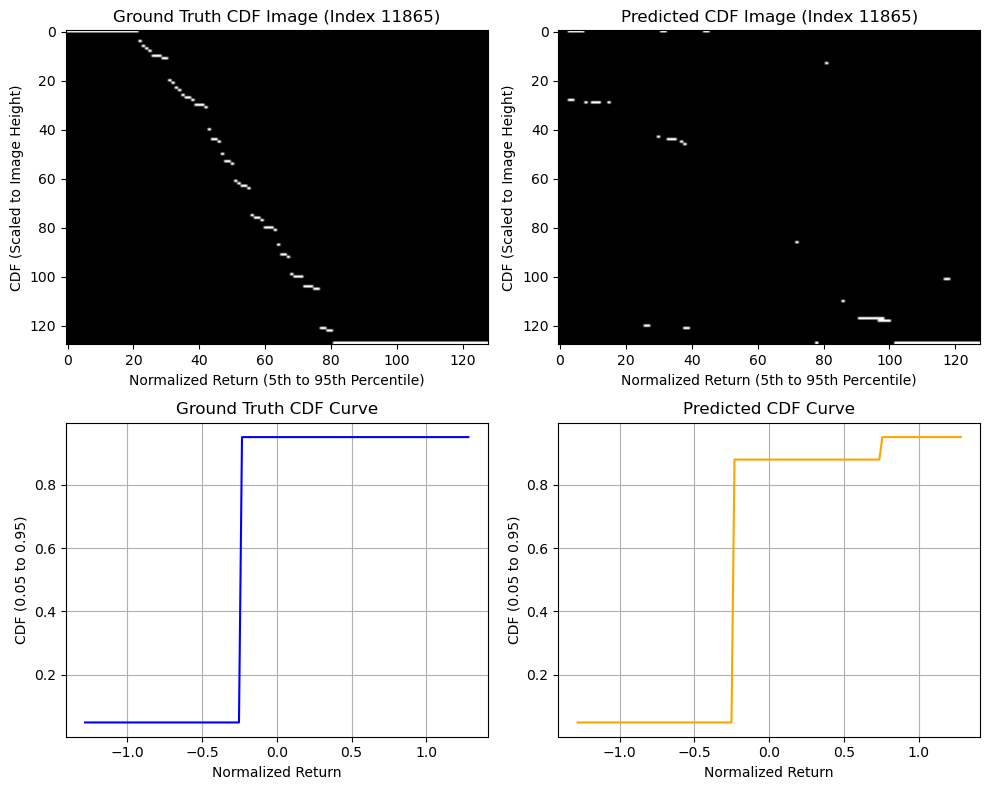

Forecast at time 11865 (Date: 2025-04-09 09:03:01.892257444):
Current Price: 79.00
Expected Normalized Return: -0.1643
Expected Price (for reference): 78.90
Forecasted CDF Values (first 5 points): [0.05 0.05 0.05 0.05 0.05]
Actual CDF Values (first 5 points): [0. 0. 0. 0. 0.]
KS Distance: 0.8791
Wasserstein Distance: 0.4914
KL Divergence (actual || forecast): 23.0397

Forecast at time 11866 (Date: 2025-04-09 09:03:01.896923864):
Current Price: 79.00
Expected Normalized Return: 0.4236
Expected Price (for reference): 79.52
Forecasted CDF Values (first 5 points): [0.05 0.05 0.05 0.05 0.05]
Actual CDF Values (first 5 points): [0. 0. 0. 0. 0.]
KS Distance: 0.5019
Wasserstein Distance: 0.2568
KL Divergence (actual || forecast): 20.9931

Forecast at time 11867 (Date: 2025-04-09 09:03:13.891558646):
Current Price: 79.00
Expected Normalized Return: 0.4034
Expected Price (for reference): 79.50
Forecasted CDF Values (first 5 points): [0.05 0.05 0.05 0.05 0.05]
Actual CDF Values (first 5 points): 

KeyboardInterrupt: 

In [5]:
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.stats import wasserstein_distance
from scipy.special import rel_entr
from sklearn.preprocessing import StandardScaler
from sklearn.isotonic import IsotonicRegression
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# Step 1: Verify GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available:", gpus)
    # Enable memory growth to prevent TensorFlow from allocating all GPU memory at once
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("No GPU detected. Falling back to CPU.")

# Data preparation
df = df_trades['dey1'][['price', 'volume']].reset_index(drop=True).copy()
date_index = df_trades['dey1'].index
df['date'] = date_index

# Step 2: Compute Distributions and Predictors
no_periods = 100
last_periods = no_periods

dist_list = []
index_list = []
std_list = []
current_prices = []

for i in range(last_periods, len(df) - no_periods):
    last_prices = df.iloc[i - last_periods:i]['price'].copy()
    fut_prices = df.iloc[i + 1:i + no_periods]['price'].copy()
    std = last_prices.diff().std() * np.sqrt(no_periods)
    if std == 0 or np.isnan(std):
        std = 1e-6
    act_price = df.iloc[i]['price']
    fut_ret = fut_prices - act_price
    fut_ret_norm = fut_ret / std
    dist_list.append(fut_ret_norm.to_list())
    index_list.append(i)
    std_list.append(std)
    current_prices.append(act_price)

dist_array = np.array(dist_list)
std_list = np.array(std_list)
current_prices = np.array(current_prices)

# Step 3: Transform CDF into Images (5th to 95th percentile)
image_height = 128
image_width = 128

all_returns = dist_array.flatten()
x_min = np.percentile(all_returns, 5)
x_max = np.percentile(all_returns, 95)
x_range = np.linspace(x_min, x_max, image_width)

Y_images = np.zeros((len(dist_list), image_height, image_width, 1))

for i in range(len(dist_list)):
    distribution = np.sort(dist_array[i])
    n = len(distribution)
    cdf_vals = np.arange(1, n + 1) / n
    cdf = interp1d(distribution, cdf_vals, kind='linear', fill_value=(0, 1), bounds_error=False)
    cdf_vals_at_x = cdf(x_range)
    
    cdf_vals_at_x = np.clip(cdf_vals_at_x, 0.05, 0.95)
    y_pixels = ((cdf_vals_at_x - 0.05) / (0.95 - 0.05)) * (image_height - 1)
    y_pixels = np.clip(y_pixels, 0, image_height - 1).astype(int)
    
    image = np.zeros((image_height, image_width, 1))
    for x in range(image_width):
        y = y_pixels[x]
        image[y, x, 0] = 1
    Y_images[i] = image

# Step 4: Construct Predictor Matrix X
volatility = np.array([df.iloc[max(0, idx - last_periods):idx]['price'].diff().std() for idx in index_list])

momentum_lookback = 50
momentum = np.array([
    df.iloc[idx]['price'] - df.iloc[max(0, idx - momentum_lookback)]['price'] if idx > momentum_lookback else 0 
    for idx in index_list
])

volume = np.array([df.iloc[idx]['volume'] for idx in index_list])

ma_period = 100
moving_average = np.array([
    df.iloc[max(0, idx - ma_period + 1):idx + 1]['price'].mean() if idx >= ma_period - 1 else np.nan 
    for idx in index_list
])

current_prices_array = np.array([df.iloc[idx]['price'] for idx in index_list])
distance_to_ma = current_prices_array - moving_average
distance_to_ma_normalized = np.zeros_like(distance_to_ma)
for i, (dist, vol) in enumerate(zip(distance_to_ma, volatility)):
    if vol == 0 or np.isnan(vol) or np.isnan(dist):
        distance_to_ma_normalized[i] = 0
    else:
        distance_to_ma_normalized[i] = dist / vol

moving_average = np.nan_to_num(moving_average, nan=0.0)

X = np.column_stack((momentum, volatility, volume, moving_average, distance_to_ma_normalized))
valid_idx = ~np.any(np.isnan(X), axis=1)
X = X[valid_idx, :]
Y_images = Y_images[valid_idx]
index_list = np.array(index_list)[valid_idx]
std_list = std_list[valid_idx]
current_prices = current_prices[valid_idx]
dist_array = dist_array[valid_idx]

# Step 5: Map Indices to Dates
index_to_date = df['date'].iloc[index_list].reset_index(drop=True)

# Step 6: Group Data by Day
data_by_day = pd.DataFrame({
    'date': index_to_date,
    'X': list(X),
    'Y_image': list(Y_images),
    'index': index_list,
    'std': std_list,
    'current_price': current_prices
})
data_by_day['date'] = pd.to_datetime(data_by_day['date'])
data_by_day['day'] = data_by_day['date'].dt.date
daily_groups = data_by_day.groupby('day')

# Step 7: Rolling Regression for Last 7 Days
last_n_days = 7
window_days = 7
all_days = sorted(daily_groups.groups.keys())
forecast_days = all_days[-last_n_days:]

# Functions for evaluation
def image_to_cdf(image, x_range, image_height):
    smoothed_image = gaussian_filter(image[:, :, 0], sigma=1)
    smoothed_image = (smoothed_image > 0.5).astype(float)
    
    y_pixels = np.argmax(smoothed_image == 1, axis=0)
    for x in range(image_width):
        if y_pixels[x] == 0 and np.sum(smoothed_image[:, x]) == 0:
            left = x - 1
            right = x + 1
            while left >= 0 or right < image_width:
                if left >= 0 and np.sum(smoothed_image[:, left]) > 0:
                    y_pixels[x] = np.argmax(smoothed_image[:, left] == 1)
                    break
                if right < image_width and np.sum(smoothed_image[:, right]) > 0:
                    y_pixels[x] = np.argmax(smoothed_image[:, right] == 1)
                    break
                left -= 1
                right += 1
    
    ir = IsotonicRegression(increasing=True)
    y_pixels = ir.fit_transform(np.arange(len(y_pixels)), y_pixels)
    y_pixels = np.clip(y_pixels, 0, image_height - 1).astype(int)
    
    cdf_vals = (y_pixels / (image_height - 1)) * (0.95 - 0.05) + 0.05
    x = x_range
    pdf = np.gradient(cdf_vals, x)
    pdf = np.maximum(pdf, 1e-10)
    area = np.sum(pdf) * (x[1] - x[0])
    pdf = pdf / area
    cdf = interp1d(x, cdf_vals, kind='linear', fill_value=(0.05, 0.95), bounds_error=False)
    return x, pdf, cdf

def compute_expected_value(x, pdf):
    return np.sum(x * pdf) * (x[1] - x[0])

# Build the CNN model
def build_cnn_model(input_dim, image_height, image_width):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dense(image_height * image_width, activation='sigmoid')(x)
    x = layers.Reshape((image_height, image_width, 1))(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    outputs = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    model = models.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

# Lists to store distribution comparison metrics
ks_distances = []
wasserstein_distances = []
kl_divergences = []

# Rolling regression
for forecast_day in forecast_days:
    day_idx = all_days.index(forecast_day)
    if day_idx < window_days:
        print(f"Skipping {forecast_day}: Not enough previous days for training.")
        continue
    
    train_days = all_days[day_idx - window_days:day_idx]
    test_day_data = daily_groups.get_group(forecast_day)
    
    X_train = []
    Y_train_images = []
    for train_day in train_days:
        day_data = daily_groups.get_group(train_day)
        X_train.extend(day_data['X'].values)
        Y_train_images.extend(day_data['Y_image'].values)
    
    X_train = np.array(X_train)
    Y_train_images = np.array(Y_train_images)
    
    if len(X_train) == 0 or len(Y_train_images) == 0:
        print(f"Skipping {forecast_day}: No training data available.")
        continue
    
    scaler = StandardScaler()
    variances = np.var(X_train, axis=0)
    if np.any(variances == 0):
        print("Warning: Zero variance in predictors:", variances)
        for j in range(X_train.shape[1]):
            if variances[j] == 0:
                X_train[:, j] += np.random.normal(0, 1e-6, X_train.shape[0])
    
    X_train = scaler.fit_transform(X_train)
    
    print(f"\nTraining for forecast day: {forecast_day}")
    print("Shape of X_train:", X_train.shape)
    print("Shape of Y_train_images:", Y_train_images.shape)
    
    # Build and train the model on GPU
    with tf.device('/GPU:0'):  # Explicitly place the model on the GPU
        model = build_cnn_model(input_dim=X_train.shape[1], image_height=image_height, image_width=image_width)
        model.fit(X_train, Y_train_images, epochs=50, batch_size=64, verbose=1)  # Increased epochs and batch size
    
    X_test = np.array(list(test_day_data['X'].values))
    X_test = scaler.transform(X_test)
    current_prices_test = test_day_data['current_price'].values
    std_test = test_day_data['std'].values
    indices_test = test_day_data['index'].values
    
    with tf.device('/GPU:0'):
        Y_pred_images = model.predict(X_test, batch_size=64, verbose=0)
    
    if len(X_test) > 0:
        sample_idx = 0
        ground_truth_image = test_day_data['Y_image'].iloc[sample_idx]
        predicted_image = Y_pred_images[sample_idx]
        predicted_image_binary = (predicted_image > 0.5).astype(float)
        
        x_gt, pdf_gt, cdf_gt = image_to_cdf(ground_truth_image, x_range, image_height)
        x_pred, pdf_pred, cdf_pred = image_to_cdf(predicted_image_binary, x_range, image_height)
        
        fig, axes = plt.subplots(2, 2, figsize=(10, 8))
        axes[0, 0].imshow(ground_truth_image[:, :, 0], cmap='gray', aspect='auto')
        axes[0, 0].set_title(f"Ground Truth CDF Image (Index {indices_test[sample_idx]})")
        axes[0, 0].set_xlabel("Normalized Return (5th to 95th Percentile)")
        axes[0, 0].set_ylabel("CDF (Scaled to Image Height)")
        
        axes[0, 1].imshow(predicted_image_binary[:, :, 0], cmap='gray', aspect='auto')
        axes[0, 1].set_title(f"Predicted CDF Image (Index {indices_test[sample_idx]})")
        axes[0, 1].set_xlabel("Normalized Return (5th to 95th Percentile)")
        axes[0, 1].set_ylabel("CDF (Scaled to Image Height)")
        
        axes[1, 0].plot(x_gt, cdf_gt(x_gt), label='Ground Truth CDF', color='blue')
        axes[1, 0].set_title("Ground Truth CDF Curve")
        axes[1, 0].set_xlabel("Normalized Return")
        axes[1, 0].set_ylabel("CDF (0.05 to 0.95)")
        axes[1, 0].grid(True)
        
        axes[1, 1].plot(x_pred, cdf_pred(x_pred), label='Predicted CDF', color='orange')
        axes[1, 1].set_title("Predicted CDF Curve")
        axes[1, 1].set_xlabel("Normalized Return")
        axes[1, 1].set_ylabel("CDF (0.05 to 0.95)")
        axes[1, 1].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    for i in range(len(X_test)):
        pred_image = Y_pred_images[i]
        pred_image_binary = (pred_image > 0.5).astype(float)
        x_forecast, pdf_forecast, cdf_forecast = image_to_cdf(pred_image_binary, x_range, image_height)
        expected_norm_return = compute_expected_value(x_forecast, pdf_forecast)
        
        current_price = current_prices_test[i]
        std = std_test[i]
        expected_price = current_price + (expected_norm_return * std)
        
        idx = indices_test[i]
        if idx + no_periods < len(df):
            actual_norm_returns = dist_array[i]
            actual_norm_returns_sorted = np.sort(actual_norm_returns)
            n_actual = len(actual_norm_returns)
            cdf_actual_empirical = np.arange(1, n_actual + 1) / n_actual
            cdf_actual = interp1d(actual_norm_returns_sorted, cdf_actual_empirical, kind='linear', fill_value=(0, 1), bounds_error=False)
            cdf_actual_vals = cdf_actual(x_range)
            cdf_actual_vals = np.clip(cdf_actual_vals, 0.05, 0.95)
            x_actual = x_range
            pdf_actual = np.gradient(cdf_actual_vals, x_actual)
            pdf_actual = np.maximum(pdf_actual, 1e-10)
            area = np.sum(pdf_actual) * (x_actual[1] - x_actual[0])
            pdf_actual = pdf_actual / area
        else:
            actual_norm_returns = np.array([])
            x_actual, pdf_actual, cdf_actual = None, None, None
        
        if actual_norm_returns.size > 0:
            common_x = np.linspace(min(x_forecast.min(), x_actual.min()), 
                                 max(x_forecast.max(), x_actual.max()), 100)
            cdf_forecast_vals = cdf_forecast(common_x)
            cdf_actual_vals = cdf_actual(common_x)
            
            ks_stat = np.max(np.abs(cdf_forecast_vals - cdf_actual_vals))
            ks_distances.append(ks_stat)
            
            wass_dist = wasserstein_distance(x_forecast, x_actual, pdf_forecast, pdf_actual)
            wasserstein_distances.append(wass_dist)
            
            pdf_forecast_interp = np.gradient(cdf_forecast_vals, common_x)
            pdf_forecast_interp = np.maximum(pdf_forecast_interp, 1e-10)
            pdf_forecast_interp /= (np.sum(pdf_forecast_interp) * (common_x[1] - common_x[0]))
            pdf_actual_interp = np.gradient(cdf_actual_vals, common_x)
            pdf_actual_interp = np.maximum(pdf_actual_interp, 1e-10)
            pdf_actual_interp /= (np.sum(pdf_actual_interp) * (common_x[1] - common_x[0]))
            
            kl_div = np.sum(rel_entr(pdf_actual_interp, pdf_forecast_interp)) * (common_x[1] - common_x[0])
            kl_divergences.append(kl_div)
            
            print(f"Forecast at time {idx} (Date: {test_day_data['date'].iloc[i]}):")
            print(f"Current Price: {current_price:.2f}")
            print(f"Expected Normalized Return: {expected_norm_return:.4f}")
            print(f"Expected Price (for reference): {expected_price:.2f}")
            print(f"Forecasted CDF Values (first 5 points): {cdf_forecast(x_forecast)[:5]}")
            print(f"Actual CDF Values (first 5 points): {cdf_actual(x_actual)[:5]}")
            print(f"KS Distance: {ks_stat:.4f}")
            print(f"Wasserstein Distance: {wass_dist:.4f}")
            print(f"KL Divergence (actual || forecast): {kl_div:.4f}")
            print()
        else:
            print(f"Forecast at time {idx} (Date: {test_day_data['date'].iloc[i]}):")
            print(f"Current Price: {current_price:.2f}")
            print(f"Expected Normalized Return: {expected_norm_return:.4f}")
            print(f"Expected Price (for reference): {expected_price:.2f}")
            print(f"Forecasted CDF Values (first 5 points): {cdf_forecast(x_forecast)[:5]}")
            print(f"Actual distribution not available (insufficient future data).")
            print()

# Compute and print average distribution comparison metrics
if len(ks_distances) > 0:
    print(f"Average KS Distance: {np.mean(ks_distances):.4f}")
    print(f"Average Wasserstein Distance: {np.mean(wasserstein_distances):.4f}")
    print(f"Average KL Divergence (actual || forecast): {np.mean(kl_divergences):.4f}")
else:
    print("No distribution comparisons available.")

In [72]:
import numpy as np
import pandas as pd

# Data preparation (assuming `df_trades['dey1']` is already defined)
df = df_trades['dey1'][['price', 'volume']].reset_index(drop=True).copy()
date_index = df_trades['dey1'].index
df['date'] = date_index

# Step 2: Compute Distributions and Predictors
no_periods = 100  # Define how many future periods to look ahead
last_periods = no_periods

dist_list = []
index_list = []
std_list = []
current_prices = []

# Group data by the same date to avoid mixing trades from different dates
daily_groups = df.groupby(df['date'])

for date, group in daily_groups:
    # Only proceed if there are enough future trades for the given date
    if len(group) < no_periods:
        continue  # Skip this group (date) if there are less than 'no_periods' future trades
    
    # For each day, we loop through the data and compute the returns
    for i in range(last_periods, len(group) - no_periods):
        # Only consider trades from the current date for 'last_periods' and 'fut_prices'
        last_prices = group.iloc[i - last_periods:i]['price'].copy()
        fut_prices = group.iloc[i + 1:i + no_periods]['price'].copy()
        
        # Calculate volatility (standard deviation)
        std = last_prices.diff().std() * np.sqrt(no_periods)
        if std == 0 or np.isnan(std):
            std = 1e-6  # Handle zero or NaN standard deviation
        
        # Get the actual price (current price)
        act_price = group.iloc[i]['price']
        
        # Calculate the future returns and normalize them by the volatility
        fut_ret = fut_prices - act_price
        fut_ret_norm = fut_ret / std
        
        # Append the computed distribution (volatility-adjusted returns) to the list
        dist_list.append(fut_ret_norm.to_list())
        index_list.append(i)
        std_list.append(std)
        current_prices.append(act_price)

# Convert lists to numpy arrays for further processing
dist_array = np.array(dist_list)
std_list = np.array(std_list)
current_prices = np.array(current_prices)


KeyboardInterrupt: 

In [70]:
from tensorflow.keras import backend as K
K.clear_session()


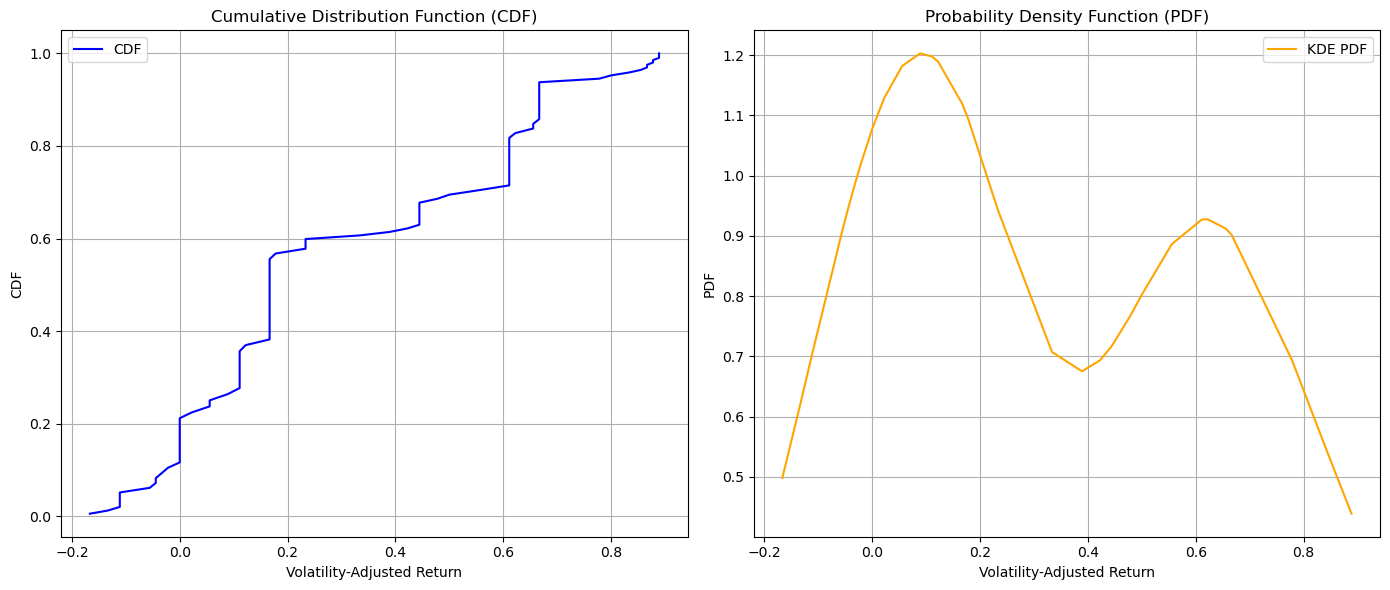

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Extract the first distribution from dist_array
first_dist = dist_array[0]

# Sort the distribution to compute the CDF
sorted_dist = np.sort(first_dist)

# Estimate the PDF using Kernel Density Estimation (KDE)
kde = gaussian_kde(sorted_dist, bw_method='silverman')  # Silverman's method for bandwidth selection
pdf_vals = kde(sorted_dist)

# Plot CDF and PDF
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Compute the CDF manually by integrating the PDF (since KDE does not directly give the CDF)
cdf_vals = np.cumsum(pdf_vals) / np.sum(pdf_vals)  # Normalize the CDF to range [0, 1]

# Plot CDF
axes[0].plot(sorted_dist, cdf_vals, label='CDF', color='blue')
axes[0].set_title('Cumulative Distribution Function (CDF)')
axes[0].set_xlabel('Volatility-Adjusted Return')
axes[0].set_ylabel('CDF')
axes[0].grid(True)
axes[0].legend()

# Plot PDF
axes[1].plot(sorted_dist, pdf_vals, label='KDE PDF', color='orange')
axes[1].set_title('Probability Density Function (PDF)')
axes[1].set_xlabel('Volatility-Adjusted Return')
axes[1].set_ylabel('PDF')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


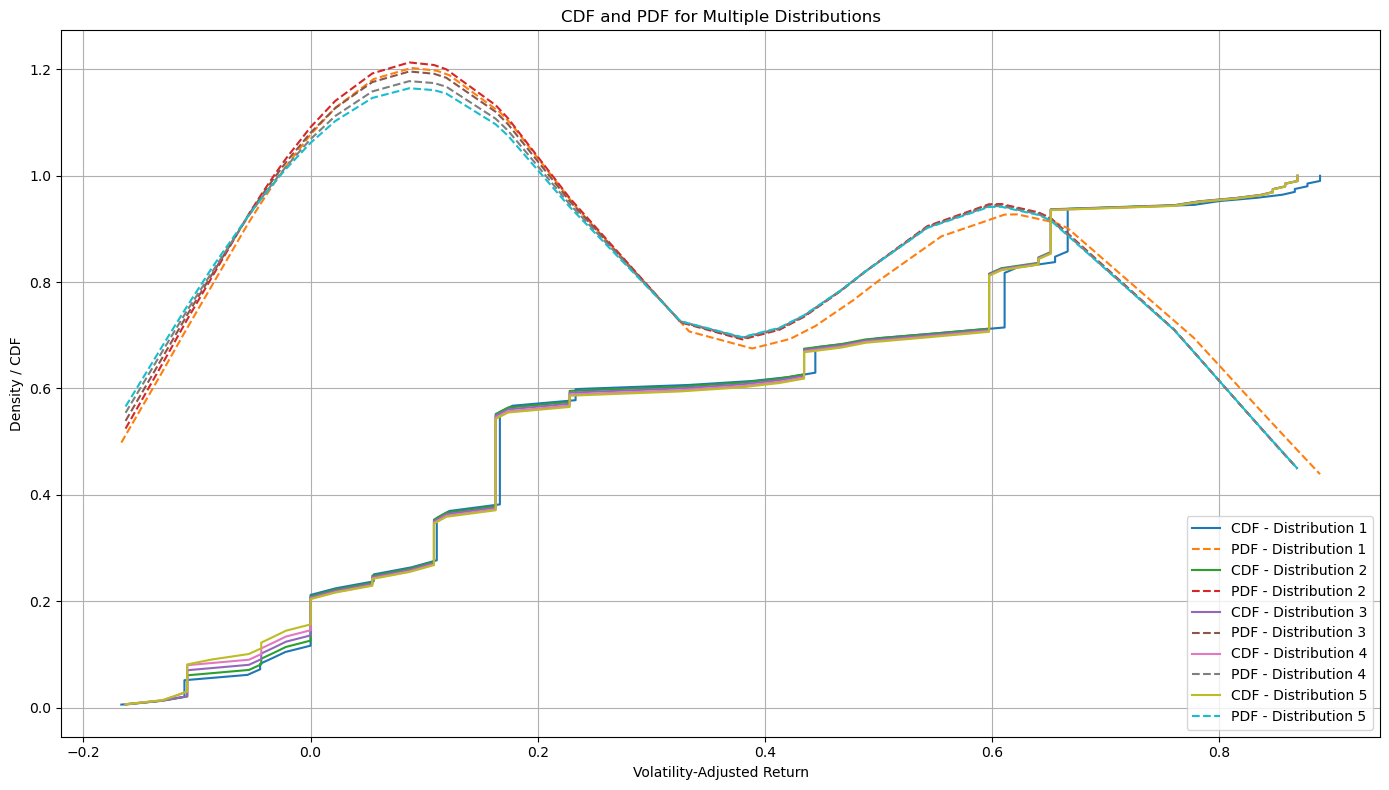

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Number of distributions to process from dist_array
num_distributions = 5  # Set this to the desired number

# Initialize the figure for plotting
plt.figure(figsize=(14, 8))

# Loop through the first 'num_distributions' distributions from dist_array
for i in range(num_distributions):
    # Extract the i-th distribution
    dist = dist_array[i]

    # Sort the distribution to compute the CDF
    sorted_dist = np.sort(dist)

    # Estimate the PDF using Kernel Density Estimation (KDE)
    kde = gaussian_kde(sorted_dist, bw_method='silverman')  # Silverman's method for bandwidth selection
    pdf_vals = kde(sorted_dist)

    # Compute the CDF manually by integrating the PDF (since KDE does not directly give the CDF)
    cdf_vals = np.cumsum(pdf_vals) / np.sum(pdf_vals)  # Normalize the CDF to range [0, 1]

    # Plot CDF
    plt.plot(sorted_dist, cdf_vals, label=f'CDF - Distribution {i + 1}')

    # Plot PDF
    plt.plot(sorted_dist, pdf_vals, label=f'PDF - Distribution {i + 1}', linestyle='--')

plt.title('CDF and PDF for Multiple Distributions')
plt.xlabel('Volatility-Adjusted Return')
plt.ylabel('Density / CDF')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
